In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from module import FlowMatchingModel 
import random

In [2]:
import Pk_library as PKL
def get_pk(mat):
    BoxSize = 25.0    
    MAS     = 'None'  
    threads = 1   
    delta = (mat-mat.mean()) / mat.std()
    pk = PKL.Pk_plane(delta,BoxSize,MAS,threads,verbose=False)
    # print(np.asarray(pk.k).max())
    return pk.k, pk.Pk

def get_xcorr(delta1, delta2):
    BoxSize = 25
    MAS1    = 'None'
    MAS2    = 'None'
    threads = 1
    XPk2D = PKL.XPk_plane(delta1, delta2, BoxSize, MAS1, MAS2, threads)
    return XPk2D.k, XPk2D.XPk / np.sqrt(XPk2D.Pk[:,0] * XPk2D.Pk[:,1])

<>:174: SyntaxWarning: invalid escape sequence '\s'
<>:185: SyntaxWarning: invalid escape sequence '\s'
<>:196: SyntaxWarning: invalid escape sequence '\s'
<>:174: SyntaxWarning: invalid escape sequence '\s'
<>:185: SyntaxWarning: invalid escape sequence '\s'
<>:196: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_217596/631981164.py:174: SyntaxWarning: invalid escape sequence '\s'
  '--', color='gray', label='$\sigma=0.2$' if i == 0 and j==0 else None)
/tmp/ipykernel_217596/631981164.py:185: SyntaxWarning: invalid escape sequence '\s'
  '--', color='gray', label='$\sigma=0.2$' if i == 0 and j==0 else None)
/tmp/ipykernel_217596/631981164.py:196: SyntaxWarning: invalid escape sequence '\s'
  '--', color='gray', label='$\sigma=0.2$' if i == 0 and j==0 else None)



Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time t

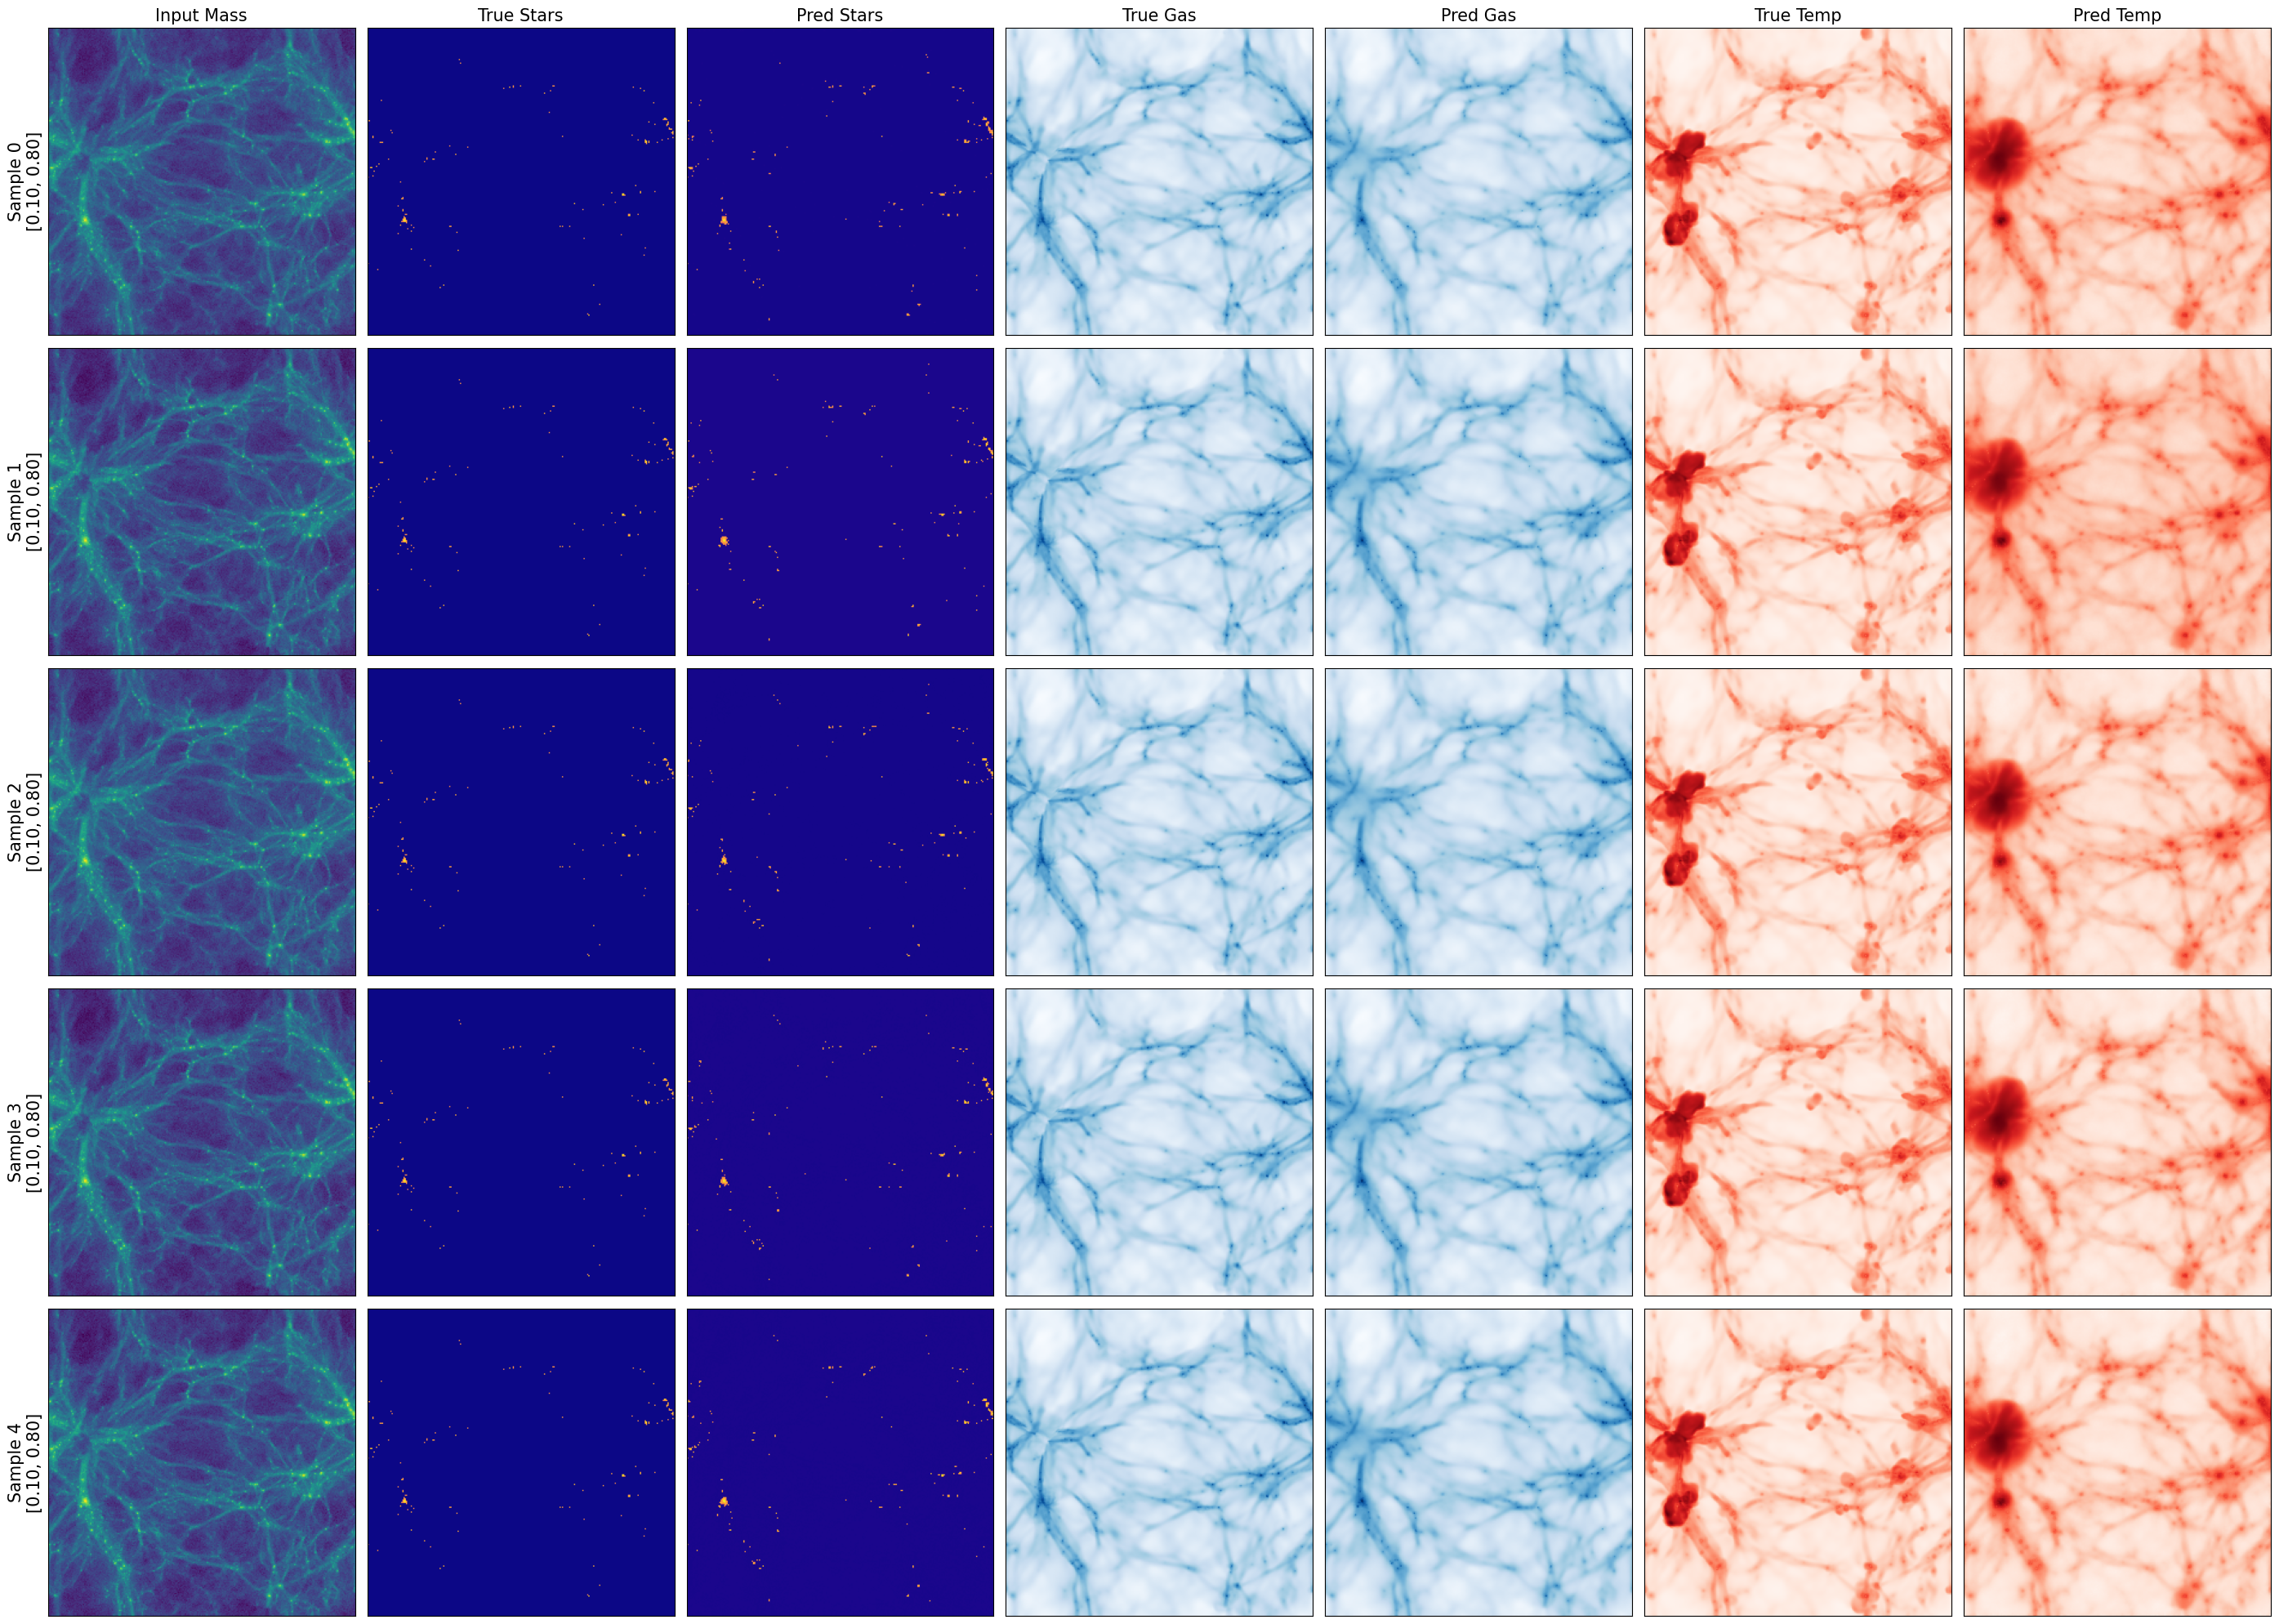

/tmp/ipykernel_217596/631981164.py:176: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axes[i,3].set_xlim(0,32.2)
/tmp/ipykernel_217596/631981164.py:187: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axes[i,4].set_xlim(0,32.2)
/tmp/ipykernel_217596/631981164.py:198: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axes[i,5].set_xlim(0,32.2)


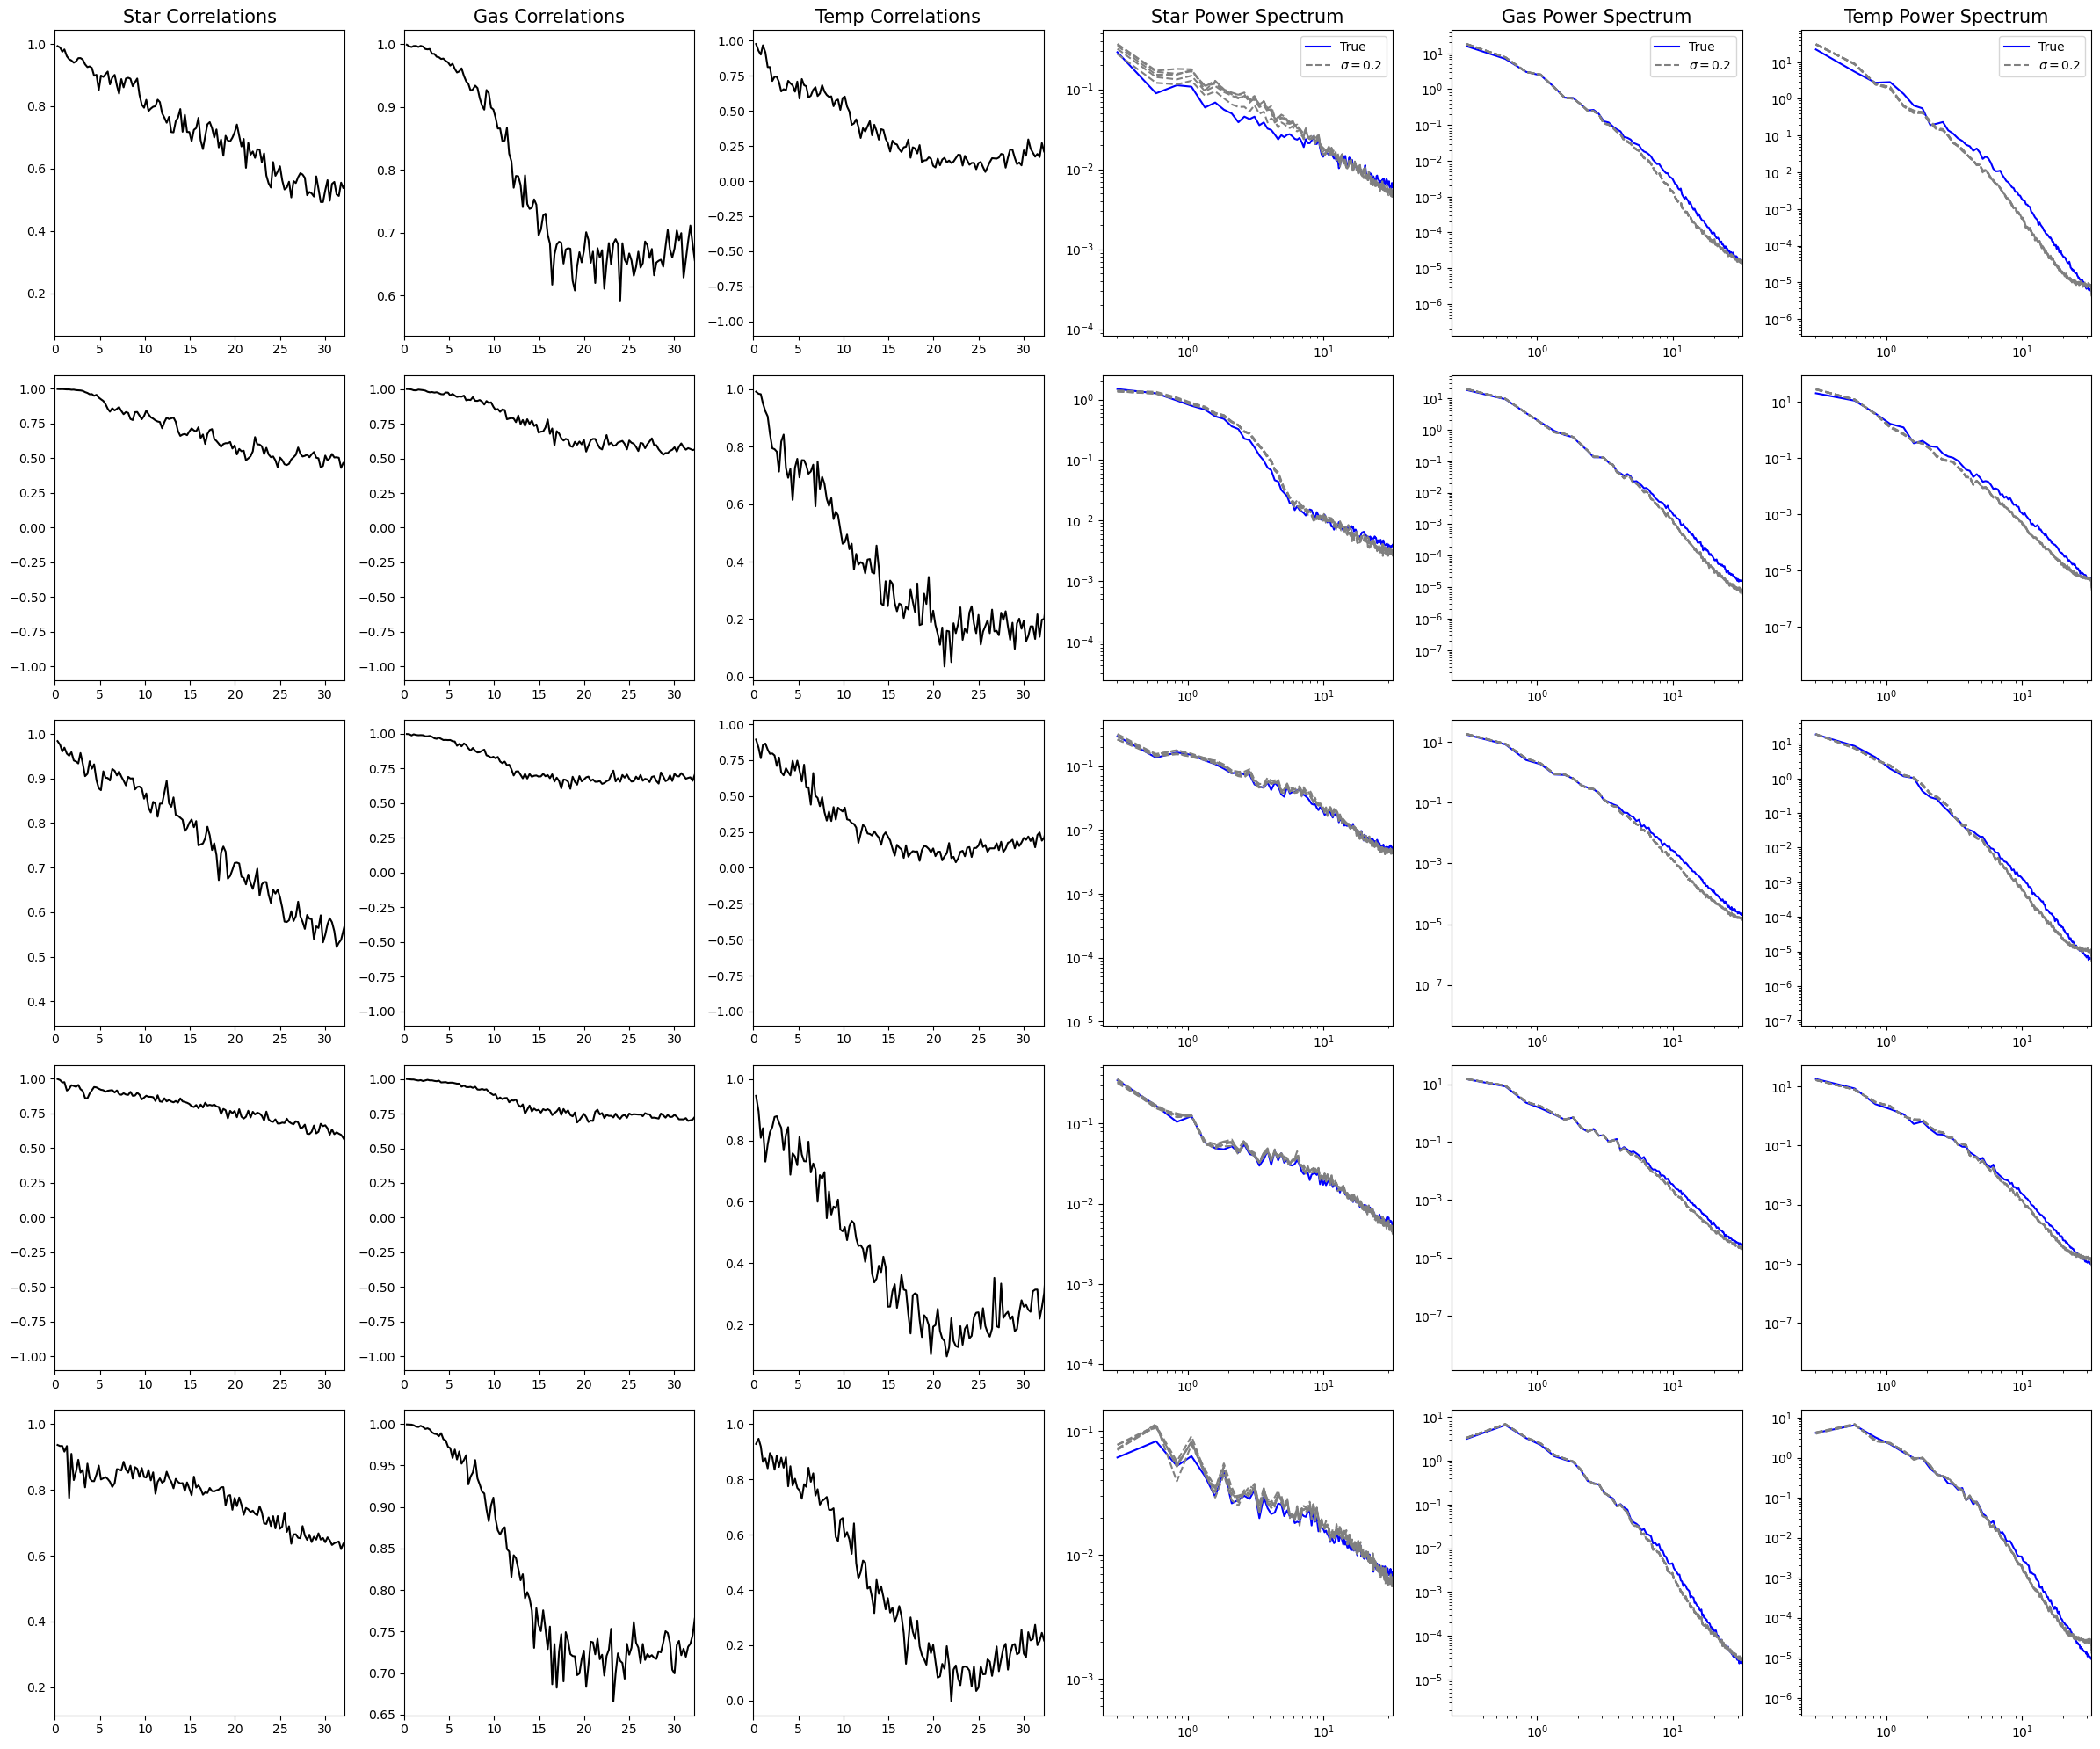

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
from scipy.fft import fft2, ifft2, fftshift

# =========================================================
# Model loading + single-sample inference
# =========================================================
def load_model(checkpoint_path, device=None):
    """Load trained flow matching model from checkpoint"""
    from module import FlowMatchingModel
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = FlowMatchingModel.load_from_checkpoint(checkpoint_path, map_location=device)
    model.to(device)
    model.eval()
    return model, device

# =========================================================
# Main plotting for 5 samples with Temperature channel
# =========================================================
def analyze_and_plot_five_samples(checkpoint_path,
                                  cdm_mass_path, star_maps_path, gas_maps_path, T_maps_path,
                                  params_path,
                                  num_steps=50):
    model, device = load_model(checkpoint_path)

    # Stats for normalization
    cdm_mass_maps = np.load(cdm_mass_path)
    tot = np.log1p(cdm_mass_maps)
    tot_mean, tot_std = tot.mean(), tot.std()
    data_stats = {'tot_mean': tot_mean, 'tot_std': tot_std}

    # indices = random.sample(range(len(cdm_mass_maps)), 5)
    indices = [0,1,2,3,4] # For 1P set

    preds_all, stars_true_all, gas_true_all, T_true_all, tot_mass_all, params_list_all = [], [], [], [], [], []
    star_pk_results, gas_pk_results, T_pk_results = [], [], []
    star_corr_results, gas_corr_results, T_corr_results = [], [], []

    for idx in indices:
        # Clean condition map
        sample_tot = np.log1p(cdm_mass_maps[idx])
        sample_tot_norm = (sample_tot - data_stats['tot_mean']) / data_stats['tot_std']

        # Noisy x0 maps
        noisy_tot_list = [
            sample_tot_norm + np.random.normal(loc=0, scale=0.2, size=(256, 256))
            for _ in range(5)
        ]

        # Load truth maps (norm by their own mean/std as before)
        star_map = np.log1p(np.load(star_maps_path)[idx])
        gas_map = np.log1p(np.load(gas_maps_path)[idx])
        T_map = np.log1p(np.load(T_maps_path)[idx])  # Add temperature map
        
        star_map_norm = (star_map - star_map.mean()) / star_map.std()
        gas_map_norm = (gas_map - gas_map.mean()) / gas_map.std()
        T_map_norm = (T_map - T_map.mean()) / T_map.std()  # Normalize temperature map
        
        astro_params = np.loadtxt(params_path)[idx//15, :2]

        # Stack all three channels: star, gas, temperature
        truth_maps = np.stack([star_map_norm, gas_map_norm, T_map_norm], axis=0)
        resnet_input_tensor = torch.tensor(truth_maps, dtype=torch.float32).unsqueeze(0).to(device)
        
        # Repeat for each noisy version
        for noisy_tot in noisy_tot_list:
            cdm_mass_tensor = torch.tensor(noisy_tot, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            cond_tensor = torch.tensor(sample_tot_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
            params_tensor = torch.tensor(astro_params, dtype=torch.float32).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model.sample(
                    cdm_mass=cdm_mass_tensor,
                    astro_params=params_tensor,
                    cdm_mass_condition=cond_tensor,
                    resnet_input=resnet_input_tensor,
                    num_steps=num_steps,
                    method='euler'
                ).cpu().numpy()[0]

            preds_all.append(pred)
            stars_true_all.append(star_map_norm)
            gas_true_all.append(gas_map_norm)
            T_true_all.append(T_map_norm)  # Store temperature truth
            tot_mass_all.append(noisy_tot)
            params_list_all.append(astro_params)

            # Power spectrum + correlation for all three channels
            # Stars
            k_star_pred, pk_star_pred = get_pk(pred[0])
            k_star_true, pk_star_true = get_pk(star_map_norm)
            star_pk_results.append({
                'k': k_star_pred,
                'pk_pred': pk_star_pred,
                'pk_true': pk_star_true,
                'error': np.abs(pk_star_pred - pk_star_true) / pk_star_true
            })

            # Gas
            k_gas_pred, pk_gas_pred = get_pk(pred[1])
            k_gas_true, pk_gas_true = get_pk(gas_map_norm)
            gas_pk_results.append({
                'k': k_gas_pred,
                'pk_pred': pk_gas_pred,
                'pk_true': pk_gas_true,
                'error': np.abs(pk_gas_pred - pk_gas_true) / pk_gas_true
            })

            # Temperature
            k_T_pred, pk_T_pred = get_pk(pred[2])
            k_T_true, pk_T_true = get_pk(T_map_norm)
            T_pk_results.append({
                'k': k_T_pred,
                'pk_pred': pk_T_pred,
                'pk_true': pk_T_true,
                'error': np.abs(pk_T_pred - pk_T_true) / pk_T_true
            })

            # Correlations
            r_star, xi_star = get_xcorr(pred[0], star_map_norm)
            r_gas, xi_gas = get_xcorr(pred[1], gas_map_norm)
            r_T, xi_T = get_xcorr(pred[2], T_map_norm)
            
            star_corr_results.append({'r': r_star, 'xi': xi_star})
            gas_corr_results.append({'r': r_gas, 'xi': xi_gas})
            T_corr_results.append({'r': r_T, 'xi': xi_T})

    # ---------- Plot maps with Temperature ----------
    fig, axes = plt.subplots(5, 7, figsize=(28, 20))
    for i in range(5):
        axes[i,0].imshow(tot_mass_all[i], cmap='viridis'); axes[i,0].set_title('Input Mass' if i==0 else '',fontsize=15)
        axes[i,1].imshow(stars_true_all[i], cmap='plasma'); axes[i,1].set_title('True Stars' if i==0 else '',fontsize=15)
        axes[i,2].imshow(preds_all[i][0], cmap='plasma'); axes[i,2].set_title('Pred Stars' if i==0 else '',fontsize=15)
        axes[i,3].imshow(gas_true_all[i], cmap='Blues'); axes[i,3].set_title('True Gas' if i==0 else '',fontsize=15)
        axes[i,4].imshow(preds_all[i][1], cmap='Blues'); axes[i,4].set_title('Pred Gas' if i==0 else '',fontsize=15)
        axes[i,5].imshow(T_true_all[i], cmap='Reds'); axes[i,5].set_title('True Temp' if i==0 else '',fontsize=15)
        axes[i,6].imshow(preds_all[i][2], cmap='Reds'); axes[i,6].set_title('Pred Temp' if i==0 else '',fontsize=15)
        
        for ax in axes[i]: ax.set_xticks([]); ax.set_yticks([])
        axes[i,0].set_ylabel(f"Sample {i}\n[{', '.join(f'{p:.2f}' for p in params_list_all[i])}]", fontsize=15)
    plt.tight_layout()
    plt.savefig('grid_with_temperature.png', dpi=150)
    plt.show()

    # ---------- Plot correlations + P(k) with Temperature ----------
    fig, axes = plt.subplots(5, 6, figsize=(24, 20))
    for i in range(5):
        # Each sample has 5 noisy runs
        base_idx = i * 5
        
        # Correlations
        axes[i,0].plot(star_corr_results[base_idx]['r'], star_corr_results[base_idx]['xi'], 'k-')
        axes[i,0].set_title('Star Correlations' if i==0 else '', fontsize=15)
        axes[i,0].set_xlim(0,32.2)
        
        axes[i,1].plot(gas_corr_results[base_idx]['r'], gas_corr_results[base_idx]['xi'], 'k-')
        axes[i,1].set_title('Gas Correlations' if i==0 else '', fontsize=15)
        axes[i,1].set_xlim(0,32.2)
        
        axes[i,2].plot(T_corr_results[base_idx]['r'], T_corr_results[base_idx]['xi'], 'k-')
        axes[i,2].set_title('Temp Correlations' if i==0 else '', fontsize=15)
        axes[i,2].set_xlim(0,32.2)
        
        # Power spectra - Stars
        k_true = star_pk_results[base_idx]['k']
        pk_true = star_pk_results[base_idx]['pk_true']
        axes[i,3].loglog(k_true, pk_true, 'b-', label='True')
        for j in range(5):
            idx_j = base_idx + j
            axes[i,3].loglog(star_pk_results[idx_j]['k'], star_pk_results[idx_j]['pk_pred'],
                             '--', color='gray', label='$\sigma=0.2$' if i == 0 and j==0 else None)
        axes[i,3].set_title('Star Power Spectrum' if i==0 else '', fontsize=15)
        axes[i,3].set_xlim(0,32.2)
        
        # Power spectra - Gas
        k_true_gas = gas_pk_results[base_idx]['k']
        pk_true_gas = gas_pk_results[base_idx]['pk_true']
        axes[i,4].loglog(k_true_gas, pk_true_gas, 'b-', label='True')
        for j in range(5):
            idx_j = base_idx + j
            axes[i,4].loglog(gas_pk_results[idx_j]['k'], gas_pk_results[idx_j]['pk_pred'],
                             '--', color='gray', label='$\sigma=0.2$' if i == 0 and j==0 else None)
        axes[i,4].set_title('Gas Power Spectrum' if i==0 else '', fontsize=15)
        axes[i,4].set_xlim(0,32.2)
        
        # Power spectra - Temperature
        k_true_T = T_pk_results[base_idx]['k']
        pk_true_T = T_pk_results[base_idx]['pk_true']
        axes[i,5].loglog(k_true_T, pk_true_T, 'b-', label='True')
        for j in range(5):
            idx_j = base_idx + j
            axes[i,5].loglog(T_pk_results[idx_j]['k'], T_pk_results[idx_j]['pk_pred'],
                             '--', color='gray', label='$\sigma=0.2$' if i == 0 and j==0 else None)
        axes[i,5].set_title('Temp Power Spectrum' if i==0 else '', fontsize=15)
        axes[i,5].set_xlim(0,32.2)
        
        if i == 0:
            axes[i,3].legend()
            axes[i,4].legend()
            axes[i,5].legend()

    plt.tight_layout()
    plt.savefig('correlation_pk_with_temperature.png', dpi=150)
    plt.show()


# Usage
analyze_and_plot_five_samples(
    checkpoint_path='/n/netscratch/iaifi_lab/Lab/msliu/FM_3channel/lightning_logs/FM_all/checkpoints/best-model-epoch=109-val_loss=0.024418.ckpt',
    cdm_mass_path='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_Mcdm_IllustrisTNG_1P_z=0.00.npy',
    star_maps_path='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_Mstar_IllustrisTNG_1P_z=0.00.npy',
    gas_maps_path='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_Mgas_IllustrisTNG_1P_z=0.00.npy',
    T_maps_path='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/Maps_T_IllustrisTNG_1P_z=0.00.npy',
    params_path='/n/netscratch/iaifi_lab/Lab/msliu/CMD/data/IllustrisTNG/params_1P_IllustrisTNG.txt',
    num_steps=50
)